# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1) A model is linear because of its parameters. In this case a model is "linear" when the variables/columns are linearly independent. When you recontruct any column from any linear combination of other columns, the variables are linearly dependent.
2) The coefficient for a dummy/one-hot-encoded variable is when the model can't functionally differentiate between linearly dependent columns, it can't assign weights, and therefore can't silce for these coefficients.
3) Not necessarily because it is not suitable to predict probabilities, which lead to innacurate classifications, especially when it comes to outliers within the data.
4) Using more variables helps improve fit on training data, but can at the same time reduce performance on the test/validation data. This is because multicolinearity results in overfitting
5) multicollinearity is when independent variables in a regrssion model are highly correlated and make it difficult to isolate their individual effects. The 2 stage least squares technique uses intrumental variables to estimate the equation. This method reduces multicollinearity by projecting the correlated predictors onto less-correlated instrumental variables, which helps mitigate the problem being dealt with originally.


6) Can incorporate nonlinear relationships in lonear model by transforming these variables while still maintaining a linear model with parameters acceptable.
7) slope coefficient in linear model is showing the expected change in the dependent variable for a one-unit increase, where all other variables remain constant.
8) train-test split is teaching model patterns and helps prevent overfitting, meanwhile k-fold cross validation splits data into k subsets.It trains k times for more robust, lower-variance, and overall less biased performace. cross validation better for small datasets and train-test better for larger ones.
9) Typically an odd number is chosen for k to help avoid ties within classification. Cross-validation helps choose an optimal k for the dataset.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [47]:
#Part One
#Checking my data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
#setting up my dataframe
df = pd.read_csv("/content/Q1_clean.csv")
df.head()


,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [48]:
#Part One (continued)
#checking for any missing values
print(df.isnull().sum())

#Drop the missing values if needed
df = df.dropna()

#Rename Neighbourhood to get rid of extra space
df = df.rename(columns={'Neighbourhood ': 'Neighbourhood'})
print(df.columns)  # Verify the rename worked

Price                   0
Review Scores Rating    0
Neighbourhood           0
Property Type           0
Room Type               0
dtype: int64
Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')


Compute the average prices and scores by Neighbourhood; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by Neighbourhood.

In [49]:
#Part one (continued)
#calculating average price and review score by neighbourhood
avg_by_neighbourhood = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print("Average Price and Review Score by Neighbourhood:")
print(avg_by_neighbourhood)

#Find which borough is most expensive?
most_expensive = avg_by_neighbourhood['Price'].idxmax()
print(f"\nMost expensive borough on average: {most_expensive}")
print(f"Average price: ${avg_by_neighbourhood.loc[most_expensive, 'Price']:.2f}")

Average Price and Review Score by Neighbourhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750

Most expensive borough on average: Manhattan
Average price: $183.66


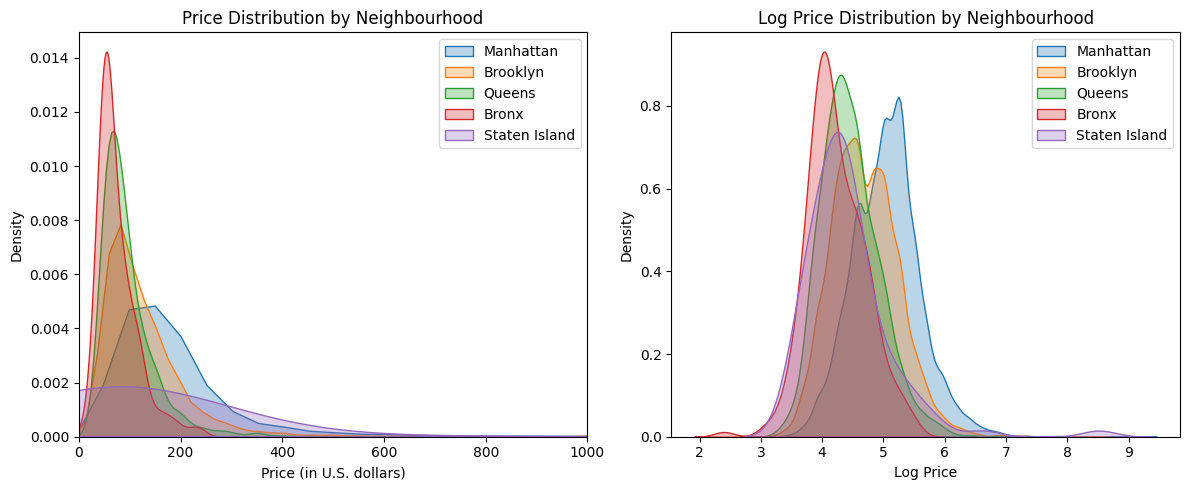

In [50]:
#Part One (continued)
#Creating the kernel density plot for price by neighbourhood
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for borough in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == borough]['Price']
    sns.kdeplot(subset, label=borough, fill=True, alpha=0.3)
plt.xlabel('Price (in U.S. dollars)')
plt.ylabel('Density')
plt.title('Price Distribution by Neighbourhood')
plt.legend()
plt.xlim(0, 1000)
# Creating the kernel density plot of log price by neighbourhood
plt.subplot(1, 2, 2)
# We add the one below to help with zero prices
df['log_price'] = np.log(df['Price'] + 1)
for borough in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == borough]['log_price']
    sns.kdeplot(subset, label=borough, fill=True, alpha=0.3)
plt.xlabel('Log Price')
plt.ylabel('Density')
plt.title('Log Price Distribution by Neighbourhood')
plt.legend()

plt.tight_layout()
plt.show()

Regress price on Neighbourhood by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

In [51]:
import statsmodels.api as sm
#Part Two
#Creating the dummy variables for Neighbourhood
# drop_first=True to avoid dummy variable trap
X_neighbourhood = pd.get_dummies(df['Neighbourhood'],
                                  prefix='hood',
                                  dtype='int',
                                  drop_first=True)

# Add intercept manually
X_neighbourhood_with_inter = sm.add_constant(X_neighbourhood)

# Run the regression
y = df['Price']
model_neighbourhood = LinearRegression().fit(X_neighbourhood, y)

# Get results for the intercept of regression
print(f"Model intercept: {model_neighbourhood.intercept_:.2f}")
coef_df = pd.DataFrame({
    'variable': X_neighbourhood.columns,
    'coefficient': model_neighbourhood.coef_
})
print(coef_df)

Model intercept: 75.28
             variable  coefficient
0       hood_Brooklyn    52.470881
1      hood_Manhattan   108.387789
2         hood_Queens    21.580735
3  hood_Staten Island    70.890169


Part Two (continued): The conditional groups and the estimated coefficients are related by giving us the same information in different ways. We see the difference between each boroughs average price point which helps us know which one is the most expensive.

Regress price on Review Scores Rating and a constant/intercept. Interpret the slope coefficient clearly in words.

In [52]:
#Part three
#Setting up the data
X_rating = df[['Review Scores Rating']]

#Running the regression
model_rating = LinearRegression().fit(X_rating, y)
y_pred = model_rating.predict(X_rating)

# Results
print(f"Intercept: ${model_rating.intercept_:.2f}")
print(f"Slope coefficient: ${model_rating.coef_[0]:.2f} per rating point")

Intercept: $60.88
Slope coefficient: $1.02 per rating point


Part three (continued): For every point increase in the review score rating, the price will increase by a dollar and two cents on average.

Regress price on both Neighbourhood and Review Scores Rating. How does the slope coefficient on Review Scores Rating change? How do the neighborhood averages change?

In [53]:
#Part Four
# Combine features
X_both = pd.concat([X_rating, X_neighbourhood], axis=1)

# Run regression
model_both = LinearRegression().fit(X_both, y)

# Results
print("Multiple Regression: Price ~ Rating + Neighbourhood")
print(f"Intercept: ${model_both.intercept_:.2f}")
coef_both = pd.DataFrame({
    'variable': X_both.columns,
    'coefficient': model_both.coef_
})
print(coef_both)

Multiple Regression: Price ~ Rating + Neighbourhood
Intercept: $-23.81
               variable  coefficient
0  Review Scores Rating     1.081116
1         hood_Brooklyn    51.704240
2        hood_Manhattan   108.228737
3           hood_Queens    21.694600
4    hood_Staten Island    71.766552


Part Four (continued): The slope coefficient on Review Scores Rating change with a drop of 23 dollars and eighty-one cents. The neighborhood averages change by many dropping a lot compared to Manhattan.

Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for Review Scores Rating. Are the slopes similar across neighborhoods, or not?

Model with separate slopes for each neighbourhood:
Slope for Bronx: 0.57
Slope for Brooklyn: 1.32
Slope for Manhattan: 1.30
Slope for Queens: 0.50
Slope for Staten Island: -31.26


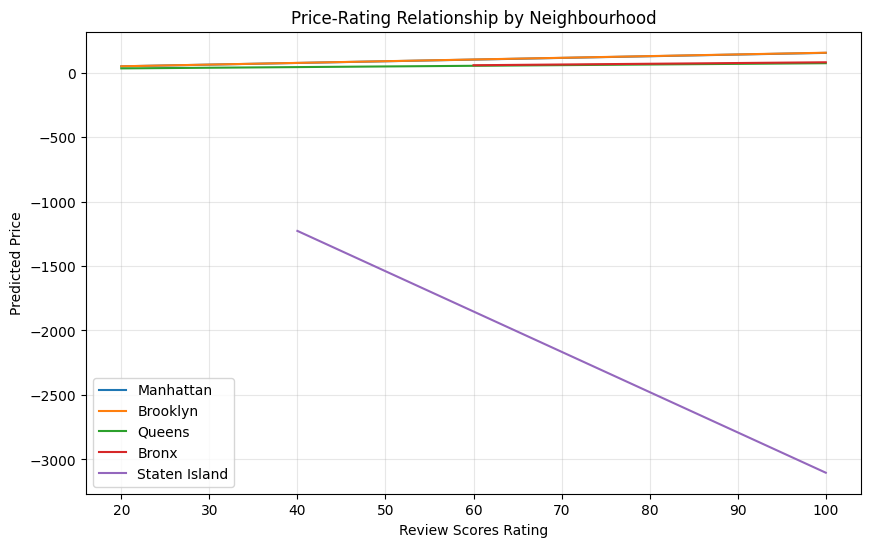

In [54]:
# Part Five:
# Create interaction terms: rating * neighbourhood
X_interaction = X_rating.copy()
for col in X_neighbourhood.columns:
    X_interaction[f'rating_x_{col}'] = X_rating['Review Scores Rating'] * X_neighbourhood[col]

# Add neighbourhood dummies
X_interaction = pd.concat([X_interaction, X_neighbourhood], axis=1)

# Run regression with interactions
model_interaction = LinearRegression().fit(X_interaction, y)

# Extract and compare slopes
print("Model with separate slopes for each neighbourhood:")

# Assuming 'Bronx' is the alphabetically first category and was dropped as reference
reference_borough_name = 'Bronx'
print(f"Slope for {reference_borough_name}: {model_interaction.coef_[0]:.2f}")

# Slopes for other neighbourhoods
for col in X_neighbourhood.columns:
    hood_name = col.replace('hood_', '')
    interaction_col_name = f'rating_x_{col}'
    # Ensure the column exists before trying to get its location
    if interaction_col_name in X_interaction.columns:
        interaction_idx = X_interaction.columns.get_loc(interaction_col_name)
        total_slope = model_interaction.coef_[0] + model_interaction.coef_[interaction_idx]
        print(f"Slope for {hood_name}: {total_slope:.2f}")
    else:
        print(f"Error: Interaction term '{interaction_col_name}' not found for {hood_name}")

# Visualize the different slopes
plt.figure(figsize=(10, 6))
for borough in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == borough]
    # Calculate slope for this borough
    if borough == reference_borough_name:
        # For the reference borough, the slope is the base coefficient for 'Review Scores Rating'
        slope = model_interaction.coef_[0]
    else:
        # For other boroughs, the slope is the base coefficient plus the interaction term's coefficient
        interaction_col_name = f'rating_x_hood_{borough}'
        # This interaction column should exist for all non-reference boroughs
        interaction_idx = X_interaction.columns.get_loc(interaction_col_name)
        slope = model_interaction.coef_[0] + model_interaction.coef_[interaction_idx]

    # Plot a representative line
    x_range = np.array([subset['Review Scores Rating'].min(),
                        subset['Review Scores Rating'].max()])
    y_range = model_interaction.intercept_ + slope * x_range
    plt.plot(x_range, y_range, label=borough)

plt.xlabel('Review Scores Rating')
plt.ylabel('Predicted Price')
plt.title('Price-Rating Relationship by Neighbourhood')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The slopes are similar in some sense except when it comes to Staten Island where there is a negative drop which is the complete opposite to the rest

Use cross validation to evaluate the models from parts 4, 5, and 6.


Rating Only:
  MSE: 22078.79 (+/- 12029.64)
  RMSE: $148.59

Neighbourhood Only:
  MSE: 21157.32 (+/- 11923.61)
  RMSE: $145.46

Rating + Neighbourhood:
  MSE: 21070.14 (+/- 11921.86)
  RMSE: $145.16

Interaction Model:
  MSE: 21328.18 (+/- 11841.51)
  RMSE: $146.04


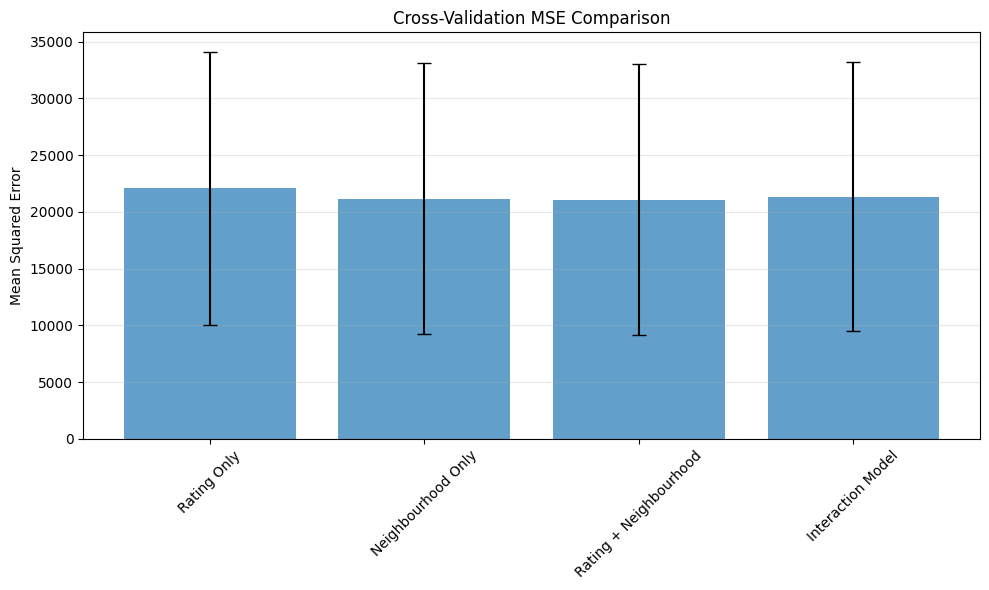


Best model based on lowest MSE: Rating + Neighbourhood


In [55]:
#Question Six:
# Define models
models = {
    'Rating Only': X_rating,
    'Neighbourhood Only': X_neighbourhood,
    'Rating + Neighbourhood': X_both,
    'Interaction Model': X_interaction
}

# Set up cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate each model
results = {}
for name, X in models.items():
    # Use negative MSE for scoring (so higher is better)
    scores = cross_val_score(LinearRegression(), X, y,
                             cv=kfold,
                             scoring='neg_mean_squared_error')

    # Convert to positive MSE
    mse_scores = -scores
    results[name] = {
        'mean_mse': mse_scores.mean(),
        'std_mse': mse_scores.std(),
        'mean_rmse': np.sqrt(mse_scores.mean()),
        'scores': mse_scores
    }

    print(f"\n{name}:")
    print(f"  MSE: {results[name]['mean_mse']:.2f} (+/- {results[name]['std_mse']:.2f})")
    print(f"  RMSE: ${results[name]['mean_rmse']:.2f}")

# Visualize comparison
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
mse_means = [results[name]['mean_mse'] for name in model_names]
mse_stds = [results[name]['std_mse'] for name in model_names]

plt.bar(model_names, mse_means, yerr=mse_stds, capsize=5, alpha=0.7)
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validation MSE Comparison')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Identify best model
best_model = min(results, key=lambda x: results[x]['mean_mse'])
print(f"\nBest model based on lowest MSE: {best_model}")

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [56]:
# Setting Up Data (loading the dataframe)
Cars = pd.read_csv("/content/cars_hw.csv")
Cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


Summarize the Price variable and create a kernel density plot. Use .groupby() and .describe() to summarize prices by Body_Type. Make a grouped kernel density plot by Body_Type. Which car types are the most expensive? Which have the most variance?

Price Summary by Body Type:
                   mean            std  count
Body_Type                                    
suv        1.176495e+06  417479.028217    206
sedan      8.097841e+05  286736.770092    227
crossover  7.050952e+05   72849.780207     21
muv        6.264211e+05  184093.488526     38
hatchback  5.339773e+05  173086.729837    484


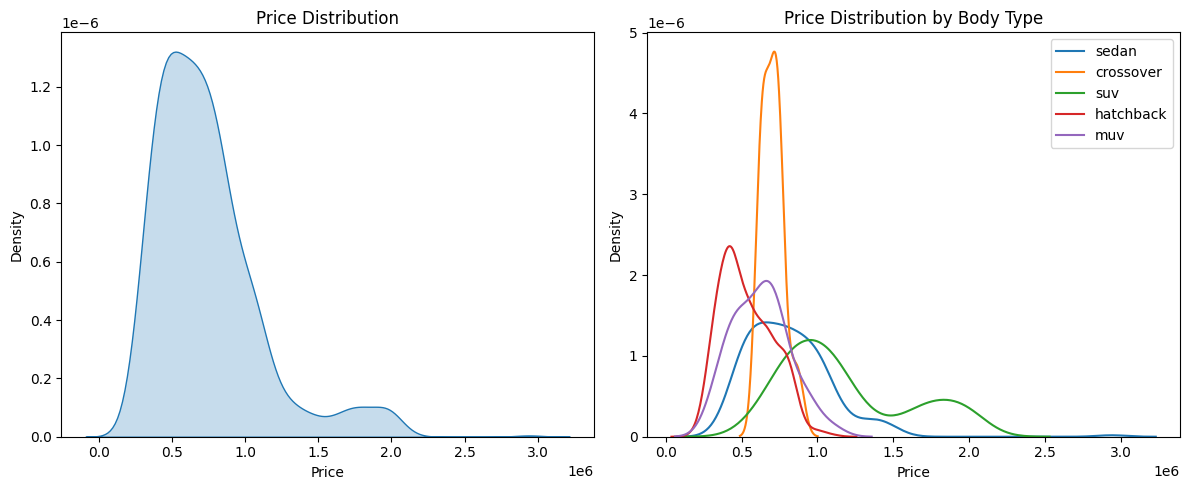


Most expensive: suv ($1,176,495)
Most variance: suv (Std: $417,479)


In [57]:
# Summary statistics
print("Price Summary by Body Type:")
print(Cars.groupby('Body_Type')['Price'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False))

# Kernel density plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(Cars['Price'], fill=True)
plt.title('Price Distribution')

plt.subplot(1, 2, 2)
for body in Cars['Body_Type'].unique():
    sns.kdeplot(Cars[Cars['Body_Type'] == body]['Price'], label=body)
plt.title('Price Distribution by Body Type')
plt.legend()

plt.tight_layout()
plt.show()

# Most expensive and most variable
body_stats = Cars.groupby('Body_Type')['Price'].agg(['mean', 'std'])
print(f"\nMost expensive: {body_stats['mean'].idxmax()} (${body_stats['mean'].max():,.0f})")
print(f"Most variance: {body_stats['std'].idxmax()} (Std: ${body_stats['std'].max():,.0f})")

SUV is most expensive and also has the most variance

Regress Price on Seating_Capacity. What's the slope coefficient? Interpret it. Now treat Seating_Capacity as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?


Seating Capacity (continuous): +$59,268 per seat

Baseline (4 seats): $188,000
5 seats: actual diff = $546,484, predicted diff = $546,484
6 seats: actual diff = $1,456,000, predicted diff = $1,456,000
7 seats: actual diff = $735,949, predicted diff = $735,949
8 seats: actual diff = $271,800, predicted diff = $271,800


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


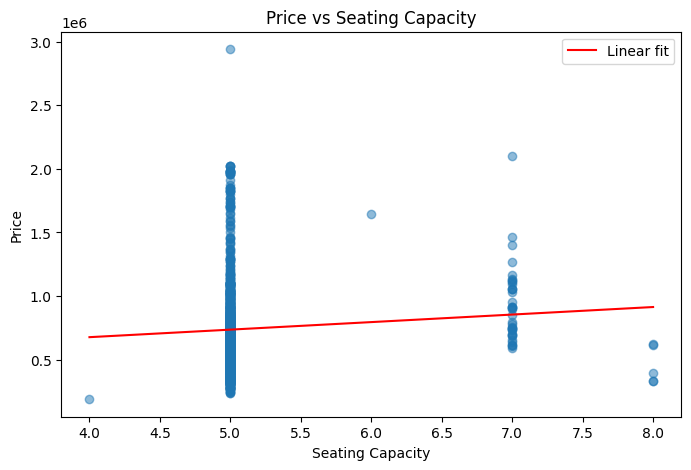

In [59]:
# Continuous model
X_seats = Cars[['Seating_Capacity']]
y = Cars['Price']
model_cont = LinearRegression().fit(X_seats, y)
print(f"\nSeating Capacity (continuous): +${model_cont.coef_[0]:,.0f} per seat")

# Categorical model (one-hot encoded)
X_cat = pd.get_dummies(Cars['Seating_Capacity'], prefix='seats', dtype='int', drop_first=True)
model_cat = LinearRegression().fit(X_cat, y)

# Compare actual means vs model
actual_means = Cars.groupby('Seating_Capacity')['Price'].mean()
print(f"\nBaseline (4 seats): ${actual_means[4]:,.0f}")
for seats in [5, 6, 7, 8]:
    if seats in actual_means.index:
        actual_diff = actual_means[seats] - actual_means[4]
        pred_diff = model_cat.coef_[X_cat.columns.get_loc(f'seats_{seats}')]
        print(f"{seats} seats: actual diff = ${actual_diff:,.0f}, predicted diff = ${pred_diff:,.0f}")

# Visualize relationship
plt.figure(figsize=(8, 5))
plt.scatter(Cars['Seating_Capacity'], Cars['Price'], alpha=0.5)
x_range = np.linspace(4, 8, 100)
plt.plot(x_range, model_cont.predict(x_range.reshape(-1, 1)), 'r-', label='Linear fit')
plt.xlabel('Seating Capacity')
plt.ylabel('Price')
plt.title('Price vs Seating Capacity')
plt.legend()
plt.show()

Not really linear but there is a difference in price with number of seats available in car

Use Make_Year to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of Age to include in a regression of Price on Age.


Optimal polynomial degree: 7


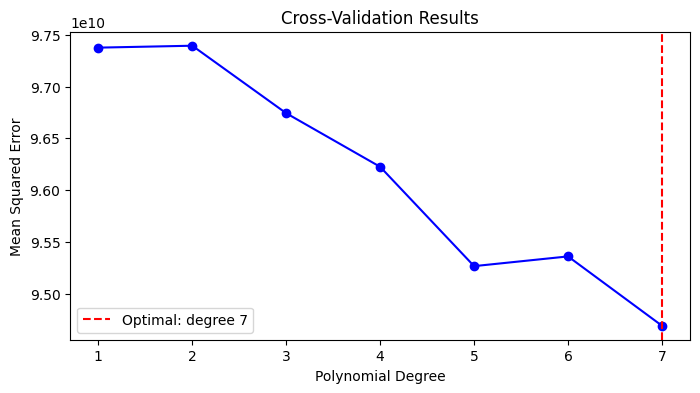

In [60]:
#Part Three
# Creating the age variable
current_year = 2025
Cars['Age'] = current_year - Cars['Make_Year']

# Making the 10-fold CV to find optimal polynomial degree
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
degrees = range(1, 8)
cv_scores = []

from sklearn.preprocessing import PolynomialFeatures

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(Cars[['Age']])
    scores = cross_val_score(LinearRegression(), X_poly, y, cv=kfold, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())

optimal_degree = degrees[np.argmin(cv_scores)]
print(f"\nOptimal polynomial degree: {optimal_degree}")

# Plotting the CV results
plt.figure(figsize=(8, 4))
plt.plot(degrees, cv_scores, 'bo-')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Cross-Validation Results')
plt.axvline(optimal_degree, color='r', linestyle='--', label=f'Optimal: degree {optimal_degree}')
plt.legend()
plt.show()

Plot Price against Age, and then model-predicted price against Age. Does the model accurately fit the patterns in the data?

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


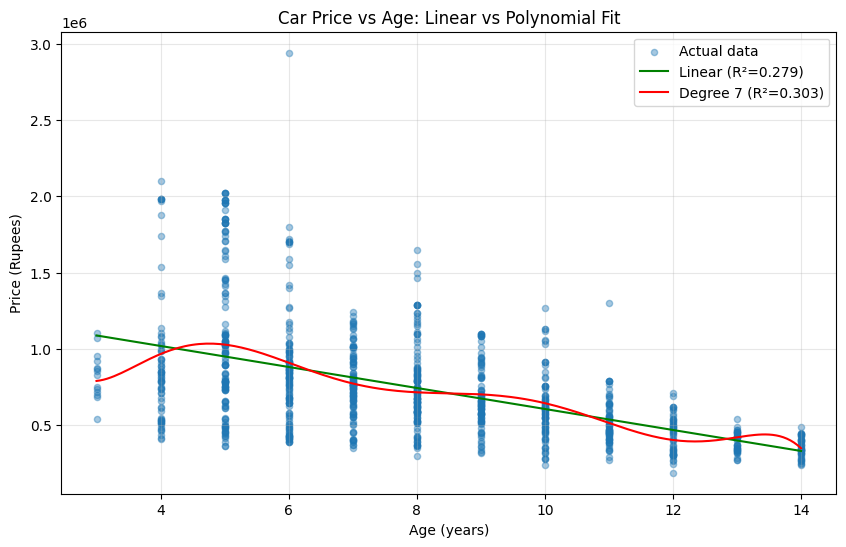

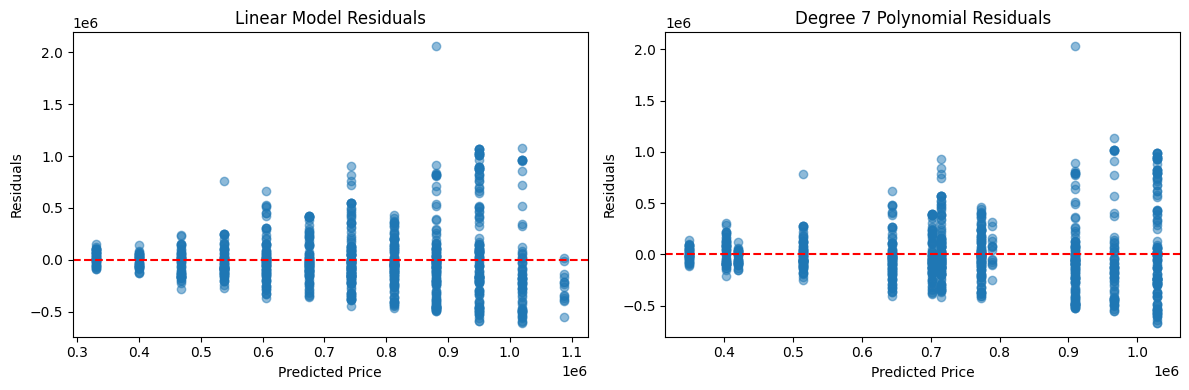


R-squared comparison:
  Linear model: 0.2790
  Polynomial (degree 7): 0.3028
  Improvement: 0.0238


In [68]:
#PArt Four
# Redefine y for the Cars DataFrame
y = Cars['Price']

# Fit best polynomial model
poly_optimal = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_poly_opt = poly_optimal.fit_transform(Cars[['Age']])
model_poly = LinearRegression().fit(X_poly_opt, y)

# Fit linear model for comparison
model_linear = LinearRegression().fit(Cars[['Age']], y)

# Create predictions for plotting
age_grid = np.linspace(Cars['Age'].min(), Cars['Age'].max(), 200).reshape(-1, 1)
linear_pred = model_linear.predict(age_grid)
poly_pred = model_poly.predict(poly_optimal.transform(age_grid))

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(Cars['Age'], y, alpha=0.4, s=20, label='Actual data')
plt.plot(age_grid, linear_pred, 'g-', label=f'Linear (R²={model_linear.score(Cars[["Age"]], y):.3f})')
plt.plot(age_grid, poly_pred, 'r-', label=f'Degree {optimal_degree} (R²={model_poly.score(X_poly_opt, y):.3f})')
plt.xlabel('Age (years)')
plt.ylabel('Price (Rupees)')
plt.title('Car Price vs Age: Linear vs Polynomial Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Residual analysis
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
resid_linear = y - model_linear.predict(Cars[['Age']])
plt.scatter(model_linear.predict(Cars[['Age']]), resid_linear, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Linear Model Residuals')

plt.subplot(1, 2, 2)
resid_poly = y - model_poly.predict(X_poly_opt)
plt.scatter(model_poly.predict(X_poly_opt), resid_poly, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title(f'Degree {optimal_degree} Polynomial Residuals')

plt.tight_layout()
plt.show()

print(f"\nR-squared comparison:")
print(f"  Linear model: {model_linear.score(Cars[['Age']], y):.4f}")
print(f"  Polynomial (degree {optimal_degree}): {model_poly.score(X_poly_opt, y):.4f}")
print(f"  Improvement: {model_poly.score(X_poly_opt, y) - model_linear.score(Cars[['Age']], y):.4f}")

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [62]:
#Part One
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

# Load data
df = pd.read_csv('heart_hw.csv')
df['treatment'] = (df['transplant'] == 'treatment').astype(int)

# Calculate ATE
control_survival = df[df['treatment']==0]['y'].mean()
treatment_survival = df[df['treatment']==1]['y'].mean()
ate = treatment_survival - control_survival

print("Average Treatment Effect (ATE):", ate)
print(f"Control survival: {control_survival:.3f}, Treatment survival: {treatment_survival:.3f}")

Average Treatment Effect (ATE): 0.23017902813299232
Control survival: 0.118, Treatment survival: 0.348


In [63]:
#Part Two
# Prepare data
X1 = df[['treatment']]
X2 = df[['treatment', 'age']]
X3 = df[['treatment', 'age']].copy()
X3['treatment_age'] = X3['treatment'] * X3['age']
y = df['y']

# Fit models
model1 = LinearRegression().fit(X1, y)
model2 = LinearRegression().fit(X2, y)
model3 = LinearRegression().fit(X3, y)

print("\nModel Results:")
print(f"Model 1 (treatment only):")
print(f"  Intercept = {model1.intercept_:.3f} (control survival)")
print(f"  Treatment = {model1.coef_[0]:.3f} (ATE)")
print(f"  R² = {model1.score(X1, y):.4f}")

print(f"\nModel 2 (treatment + age):")
print(f"  Intercept = {model2.intercept_:.3f}")
print(f"  Treatment = {model2.coef_[0]:.3f}")
print(f"  Age = {model2.coef_[1]:.3f}")
print(f"  R² = {model2.score(X2, y):.4f}")

print(f"\nModel 3 (treatment + age + interaction):")
print(f"  Intercept = {model3.intercept_:.3f}")
print(f"  Treatment = {model3.coef_[0]:.3f}")
print(f"  Age = {model3.coef_[1]:.3f}")
print(f"  Treatment×Age = {model3.coef_[2]:.3f}")
print(f"  R² = {model3.score(X3, y):.4f}")


Model Results:
Model 1 (treatment only):
  Intercept = 0.118 (control survival)
  Treatment = 0.230 (ATE)
  R² = 0.0592

Model 2 (treatment + age):
  Intercept = 0.702
  Treatment = 0.265
  Age = -0.014
  R² = 0.1468

Model 3 (treatment + age + interaction):
  Intercept = 0.355
  Treatment = 0.908
  Age = -0.006
  Treatment×Age = -0.015
  R² = 0.1717


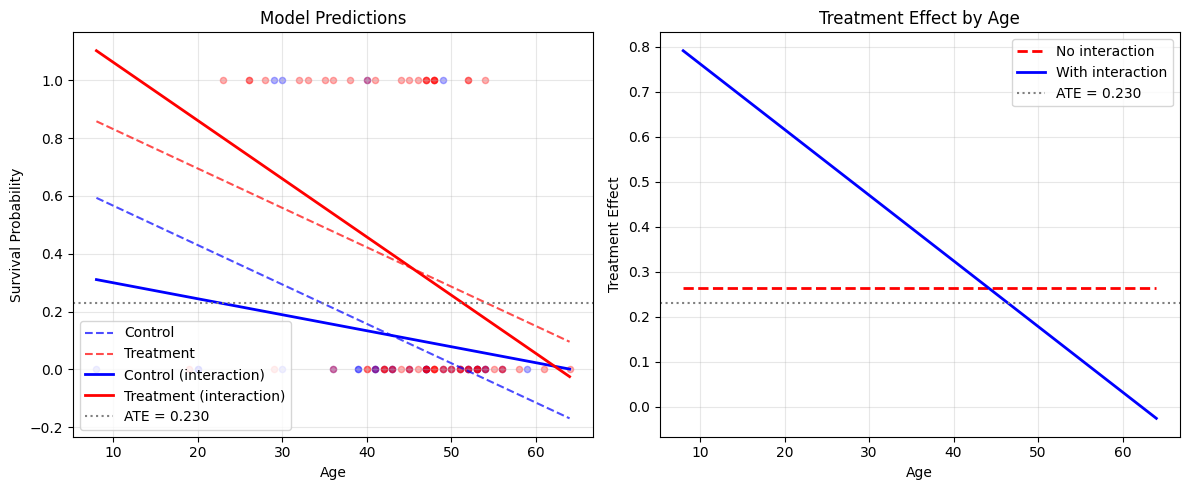


Key Insights:
- ATE overestimates benefit for ages < 16
- ATE underestimates benefit for ages > 16
- Interaction model shows treatment effect decreases with age


In [64]:
#Part Three
# Create predictions across age range
ages = np.linspace(df['age'].min(), df['age'].max(), 100)

# Model 2 predictions
control_pred2 = model2.intercept_ + model2.coef_[1] * ages
treat_pred2 = model2.intercept_ + model2.coef_[0] + model2.coef_[1] * ages

# Model 3 predictions
control_pred3 = model3.intercept_ + model3.coef_[1] * ages
treat_pred3 = model3.intercept_ + model3.coef_[0] + model3.coef_[1] * ages + model3.coef_[2] * ages

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ages, control_pred2, 'b--', label='Control', alpha=0.7)
plt.plot(ages, treat_pred2, 'r--', label='Treatment', alpha=0.7)
plt.plot(ages, control_pred3, 'b-', label='Control (interaction)', linewidth=2)
plt.plot(ages, treat_pred3, 'r-', label='Treatment (interaction)', linewidth=2)
plt.axhline(y=ate, color='gray', linestyle=':', label=f'ATE = {ate:.3f}')
plt.scatter(df[df['treatment']==0]['age'], df[df['treatment']==0]['y'], alpha=0.3, c='blue', s=20)
plt.scatter(df[df['treatment']==1]['age'], df[df['treatment']==1]['y'], alpha=0.3, c='red', s=20)
plt.xlabel('Age')
plt.ylabel('Survival Probability')
plt.title('Model Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
treat_effect2 = treat_pred2 - control_pred2
treat_effect3 = treat_pred3 - control_pred3
plt.plot(ages, treat_effect2, 'r--', label='No interaction', linewidth=2)
plt.plot(ages, treat_effect3, 'b-', label='With interaction', linewidth=2)
plt.axhline(y=ate, color='gray', linestyle=':', label=f'ATE = {ate:.3f}')
plt.xlabel('Age')
plt.ylabel('Treatment Effect')
plt.title('Treatment Effect by Age')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Insights:")
print(f"- ATE overestimates benefit for ages < {ages[np.argmin(np.abs(treat_effect2 - ate))]:.0f}")
print(f"- ATE underestimates benefit for ages > {ages[np.argmin(np.abs(treat_effect2 - ate))]:.0f}")
print(f"- Interaction model shows treatment effect {'increases' if model3.coef_[2] > 0 else 'decreases'} with age")

In [65]:
# 10-fold cross-validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

models = {'Treatment only': X1, 'Treatment + Age': X2, 'Treatment + Age + Interaction': X3}

print("\n10-Fold Cross-Validation Results:")
print("=" * 60)

for name, X in models.items():
    cv_mse = cross_val_score(LinearRegression(), X, y, cv=kfold, scoring='neg_mean_squared_error')
    cv_r2 = cross_val_score(LinearRegression(), X, y, cv=kfold, scoring='r2')

    print(f"\n{name}:")
    print(f"  MSE: {-cv_mse.mean():.4f} (+/- {cv_mse.std():.4f})")
    print(f"  RMSE: {np.sqrt(-cv_mse.mean()):.4f}")
    print(f"  R²: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")


10-Fold Cross-Validation Results:

Treatment only:
  MSE: 0.1931 (+/- 0.0422)
  RMSE: 0.4394
  R²: -0.0417 (+/- 0.2011)

Treatment + Age:
  MSE: 0.1773 (+/- 0.0476)
  RMSE: 0.4210
  R²: 0.0225 (+/- 0.2454)

Treatment + Age + Interaction:
  MSE: 0.1751 (+/- 0.0539)
  RMSE: 0.4185
  R²: 0.0434 (+/- 0.2060)


In [66]:
#Final Part (Summarizing all of the analysis completed)
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

print(f"""
1. Average Treatment Effect: {ate:.3f}
   → Transplant patients are {abs(ate)*100:.1f}% more likely to survive 3 years

2. Adding age control changed treatment effect from {model1.coef_[0]:.3f} to {model2.coef_[0]:.3f}
   → Age is a confounder

3. Interaction model shows treatment effect varies by age:
   → Treatment effect at age {int(df['age'].min())}: {model3.coef_[0] + model3.coef_[2]*df['age'].min():.3f}
   → Treatment effect at age {int(df['age'].max())}: {model3.coef_[0] + model3.coef_[2]*df['age'].max():.3f}

4. Cross-validation shows interaction model performs best:
   → R²: {cv_r2.mean():.4f} vs {cross_val_score(LinearRegression(), X2, y, cv=kfold, scoring='r2').mean():.4f}
""")

print("\n" + "="*60)
print("DEPLOYMENT CONCERNS")
print("="*60)

print("""
1. **Confounding**: Age is controlled, but health status, comorbidities unmeasured
2. **Selection bias**: Healthier patients may be selected for transplant
3. **Linear probability**: Model can predict outside [0,1]; logistic regression would be better
4. **Causality**: Observational data cannot prove causation
5. **Sample size**: n=103 may not be sufficient for stable estimates
6. **Ethics**: Using models for prioritization could perpetuate bias
7. **Generalizability**: Results may not apply to different populations or time periods
""")


SUMMARY

1. Average Treatment Effect: 0.230
   → Transplant patients are 23.0% more likely to survive 3 years

2. Adding age control changed treatment effect from 0.230 to 0.265
   → Age is a confounder

3. Interaction model shows treatment effect varies by age:
   → Treatment effect at age 8: 0.791
   → Treatment effect at age 64: -0.026

4. Cross-validation shows interaction model performs best:
   → R²: 0.0434 vs 0.0225


DEPLOYMENT CONCERNS

1. **Confounding**: Age is controlled, but health status, comorbidities unmeasured
2. **Selection bias**: Healthier patients may be selected for transplant
3. **Linear probability**: Model can predict outside [0,1]; logistic regression would be better
4. **Causality**: Observational data cannot prove causation
5. **Sample size**: n=103 may not be sufficient for stable estimates
6. **Ethics**: Using models for prioritization could perpetuate bias
7. **Generalizability**: Results may not apply to different populations or time periods

